### Module Import

In [1]:
# https://github.com/HideOnHouse/TorchBase

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dataset import *
from model import get_Model
from learning import *
from inference import *

torch.__version__

'1.11.0+cu102'

### 함수 선언

In [2]:
def label2int(data, label_tags):
    for i in range(len(data)):
        data.iloc[i,1] = label_tags.index(data.iloc[i, 1])
    return data


def draw_history(history):
    train_loss = history["train_loss"]
    train_acc = history["train_acc"]
    valid_loss = history["valid_loss"]
    valid_acc = history["valid_acc"]

    plt.subplot(2,1,1)
    plt.title("Loss")
    plt.plot(train_loss, label="train")
    plt.plot(valid_loss, label="valid")
    plt.legend()

    plt.subplot(2,1,2)
    plt.title('Accuracy')
    plt.plot(train_acc, label="train")
    plt.plot(valid_acc, label="valid")
    plt.legend()

    plt.show()

In [3]:
# label_tags
label_tags = ['불안', '슬픔', '기쁨']

train_path = "train.csv"
test_path = "test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

train_data = label2int(train_data, label_tags)
test_data = label2int(test_data, label_tags)

# your Data Pre-Processing
train_x, train_y = train_data.iloc[:, :1], train_data.iloc[:, 1:]
test_x, test_y = test_data.iloc[:, :1], test_data.iloc[:, 1:]

# data split
train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, stratify=train_y, random_state=17, test_size=0.05)

# Check Train, Valid, Test Image's Shape
print("The Shape of Train Input: ", train_x.shape)
print("The Shape of Valid Input: ", valid_x.shape)
print("The Shape of Test Input: ", test_x.shape)

# Check Train, Valid Label's Shape
print("The Shape of Train Labels: ", train_y.shape)
print("The Shape of Valid Labels: ", valid_y.shape)
print("The Shape of Valid Labels: ", test_y.shape)

The Shape of Train Input:  (9405, 1)
The Shape of Valid Input:  (495, 1)
The Shape of Test Input:  (100, 1)
The Shape of Train Labels:  (9405, 1)
The Shape of Valid Labels:  (495, 1)
The Shape of Valid Labels:  (100, 1)


## Model 1
+ basis Model

### Klue BERT-base

In [4]:
model_path = "klue/bert-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [5]:
class_name = "MyModel_1"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [6]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:42,  2.86it/s, epoch=1/10, loss=0.018362, acc=0.747]
16it [00:01,  8.28it/s, loss=0.015583, acc=0.798]

294it [01:42,  2.86it/s, epoch=2/10, loss=0.013097, acc=0.829]
16it [00:01,  8.43it/s, loss=0.016056, acc=0.774]

294it [01:43,  2.83it/s, epoch=3/10, loss=0.009892, acc=0.879]
16it [00:01,  8.47it/s, loss=0.015656, acc=0.794]

294it [01:43,  2.83it/s, epoch=4/10, loss=0.006310, acc=0.928]
16it [00:01,  8.36it/s, loss=0.018202, acc=0.804]

294it [01:43,  2.83it/s, epoch=5/10, loss=0.004147, acc=0.956]
16it [00:01,  8.37it/s, loss=0.019289, acc=0.814]

294it [01:43,  2.85it/s, epoch=6/10, loss=0.002972, acc=0.968]
16it [00:01,  8.38it/s, loss=0.023458, acc=0.808]

294it [01:43,  2.83it/s, epoch=7/10, loss=0.002057, acc=0.979]
16it [00:01,  8.27it/s, loss=0.024076, acc=0.802]

294it [01:43,  2.83it/s, epoch=8/10, loss=0.002158, acc=0.978]
16it [00:01,  8.27it/s, loss=0.027676, acc=0.784]

294it [01:44,  2.82it/

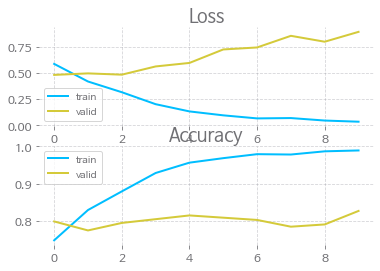

In [7]:
draw_history(history)

In [8]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00, 10.16it/s, loss=0.037529, acc=0.830]
test loss : 0.938237
test acc : 0.830


In [9]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [4]:
model_path = "klue/roberta-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [5]:
class_name = "MyModel_1"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Some weights of the model checkpoint at klue/roberta-base were not used when initializing RobertaModel: ['lm_head.decoder.weight', 'lm_head.dense.weight', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for

'cuda'

In [6]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:41,  2.89it/s, epoch=1/10, loss=0.019985, acc=0.724]
16it [00:01,  8.39it/s, loss=0.017184, acc=0.766]

294it [01:43,  2.85it/s, epoch=2/10, loss=0.015546, acc=0.796]
16it [00:01,  8.40it/s, loss=0.017331, acc=0.784]

294it [01:43,  2.83it/s, epoch=3/10, loss=0.013130, acc=0.831]
16it [00:01,  8.43it/s, loss=0.015739, acc=0.792]

294it [01:42,  2.85it/s, epoch=4/10, loss=0.010738, acc=0.868]
16it [00:01,  8.38it/s, loss=0.015007, acc=0.808]

294it [01:43,  2.83it/s, epoch=5/10, loss=0.008749, acc=0.897]
16it [00:01,  8.42it/s, loss=0.017167, acc=0.766]

294it [01:43,  2.85it/s, epoch=6/10, loss=0.006987, acc=0.923]
16it [00:01,  8.29it/s, loss=0.017774, acc=0.820]

294it [01:43,  2.83it/s, epoch=7/10, loss=0.005596, acc=0.941]
16it [00:01,  8.26it/s, loss=0.019174, acc=0.808]

294it [01:43,  2.83it/s, epoch=8/10, loss=0.004297, acc=0.957]
16it [00:01,  8.54it/s, loss=0.025851, acc=0.802]

294it [01:43,  2.84it/

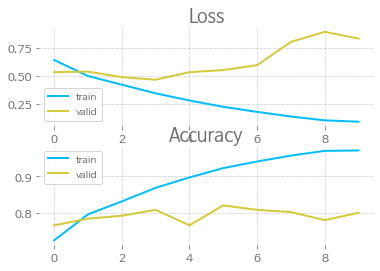

In [7]:
draw_history(history)

In [8]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00, 10.25it/s, loss=0.037632, acc=0.800]
test loss : 0.940798
test acc : 0.800


In [9]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}_roberta.pt")
with open(f"models/{file_name}_roberta_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Model 2
+ Mean Pooling

### Klue BERT-base

In [4]:
model_path = "klue/bert-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [5]:
class_name = "MyModel_2"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [6]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:41,  2.89it/s, epoch=1/10, loss=0.018094, acc=0.749]
16it [00:01,  8.44it/s, loss=0.015723, acc=0.796]

294it [01:43,  2.85it/s, epoch=2/10, loss=0.012960, acc=0.829]
16it [00:01,  8.13it/s, loss=0.015696, acc=0.796]

294it [01:44,  2.83it/s, epoch=3/10, loss=0.008972, acc=0.887]
16it [00:01,  8.26it/s, loss=0.016723, acc=0.802]

294it [01:43,  2.83it/s, epoch=4/10, loss=0.006125, acc=0.929]
16it [00:01,  8.36it/s, loss=0.020037, acc=0.808]

294it [01:43,  2.84it/s, epoch=5/10, loss=0.003651, acc=0.959]
16it [00:01,  8.20it/s, loss=0.024094, acc=0.782]

294it [01:43,  2.84it/s, epoch=6/10, loss=0.002209, acc=0.975]
16it [00:01,  8.10it/s, loss=0.024233, acc=0.798]

294it [01:43,  2.84it/s, epoch=7/10, loss=0.001858, acc=0.980]
16it [00:01,  8.49it/s, loss=0.030346, acc=0.800]

294it [01:43,  2.85it/s, epoch=8/10, loss=0.001523, acc=0.983]
16it [00:01,  8.31it/s, loss=0.033945, acc=0.788]

294it [01:43,  2.84it/

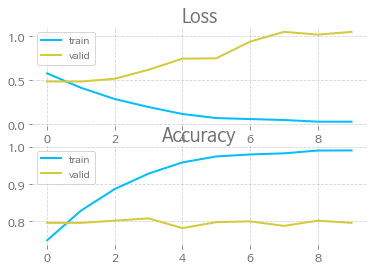

In [7]:
draw_history(history)

In [8]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00, 10.07it/s, loss=0.039672, acc=0.750]
test loss : 0.991802
test acc : 0.750


In [9]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [20]:
model_path = "klue/roberta-base"

train_dataset = MyDataset(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [21]:
class_name = "MyModel_2"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

device

Some weights of the model checkpoint at klue/roberta-base were not used when initializing RobertaModel: ['lm_head.dense.bias', 'lm_head.decoder.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.dense.weight', 'lm_head.decoder.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for

'cuda'

In [22]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:41,  2.89it/s, epoch=1/10, loss=0.019415, acc=0.736]
16it [00:01,  8.17it/s, loss=0.017787, acc=0.788]

294it [01:43,  2.84it/s, epoch=2/10, loss=0.014681, acc=0.809]
16it [00:02,  7.97it/s, loss=0.020419, acc=0.749]

294it [01:43,  2.84it/s, epoch=3/10, loss=0.012816, acc=0.841]
16it [00:01,  8.11it/s, loss=0.015831, acc=0.804]

294it [01:42,  2.86it/s, epoch=4/10, loss=0.010308, acc=0.876]
16it [00:01,  8.30it/s, loss=0.015723, acc=0.802]

294it [01:42,  2.87it/s, epoch=5/10, loss=0.008360, acc=0.907]
16it [00:02,  7.70it/s, loss=0.017341, acc=0.816]

294it [01:42,  2.86it/s, epoch=6/10, loss=0.006898, acc=0.927]
16it [00:01,  8.10it/s, loss=0.017577, acc=0.804]

294it [01:43,  2.84it/s, epoch=7/10, loss=0.005933, acc=0.939]
16it [00:01,  8.09it/s, loss=0.019455, acc=0.812]

294it [01:43,  2.84it/s, epoch=8/10, loss=0.004887, acc=0.949]
16it [00:01,  8.20it/s, loss=0.022017, acc=0.814]

294it [01:43,  2.84it/

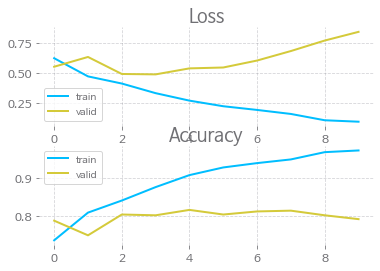

In [23]:
draw_history(history)

In [24]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00, 10.24it/s, loss=0.041255, acc=0.790]
test loss : 1.031372
test acc : 0.790


In [25]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Model 3
+ CLS Token
+ Contrastive Loss 적용

In [4]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))


        return loss_contrastive
    
    
class My_Contrastive_Loss(nn.Module):
    def __init__(self, p=0.1, margin=2.0):
        super(My_Contrastive_Loss, self).__init__()
        
        self.p = p
        self.contrastive = ContrastiveLoss(margin)
        self.base = nn.CrossEntropyLoss()
        
    def forward(self, y_hat, output1, output2, target, c_y):
        return ((1-self.p) * self.base(y_hat, target)) + (self.p * self.contrastive(output1, output2, c_y))

In [5]:
def calc_acc(output, label):
    o_val, o_idx = torch.max(output, dim=-1)
    l_val, l_idx = torch.max(label, dim=-1)
    acc = (o_idx == l_idx).sum().item()
    return acc

def train_contrastive(model, device, optimizer, criterion, epochs, train_loader, valid_loader=None) -> dict:
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param optimizer: your optimizer
    :param criterion: loss function
    :param epoch: train epochs
    :param train_loader: train dataset
    :param valid_loader: valid dataset
    :return: history dictionary that contains train_loss, train_acc, valid_loss, valid_acc as list
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'valid_loss': [],
        'valid_acc': []
    }
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_acc = 0

        # in notebook
        # pabr = notebook.tqdm(enumerate(train_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(train_loader), file=sys.stdout)
        for batch_idx, (x, c, y) in pbar:
            x_input_ids, x_att_mask = x[0].to(device), x[1].to(device)
            c_input_ids, c_att_mask = c[0].to(device), c[1].to(device)
            target, c_y = y[0].to(device), y[1].to(device)

            optimizer.zero_grad()
            predict, output1, output2 = model(x_input_ids, x_att_mask, c_input_ids, c_att_mask)
            loss = criterion(predict, output1, output2, target, c_y)
            acc = calc_acc(predict, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

            acc = train_acc / (batch_idx * train_loader.batch_size + len(target))
            loss = train_loss / (batch_idx * train_loader.batch_size + len(target))
            pbar.set_postfix(epoch=f'{epoch}/{epochs}', loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

        train_loss = train_loss / len(train_loader)
        train_acc = train_acc / len(train_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if valid_loader is not None:
            valid_loss, valid_acc = evaluate_contrastive(model, device, criterion, valid_loader)

            history['valid_loss'].append(valid_loss)
            history['valid_acc'].append(valid_acc)
        print()

    return history


def evaluate_contrastive(model, device, criterion, data_loader):
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param criterion: loss function
    :param data_loader: valid or test Datasets
    :return: (valid or test) loss and acc
    """
    model.eval()
    total_loss = total_acc = 0

    with torch.no_grad():
        # in notebook
        # pabr = notebook.tqdm(enumerate(valid_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(data_loader), file=sys.stdout)

        for batch_idx, (x, c, y) in pbar:
            x_input_ids, x_att_mask = x[0].to(device), x[1].to(device)
            c_input_ids, c_att_mask = c[0].to(device), c[1].to(device)
            target, c_y = y[0].to(device), y[1].to(device)

            predict, output1, output2 = model(x_input_ids, x_att_mask, c_input_ids, c_att_mask)
            loss = criterion(predict, output1, output2, target, c_y)
            acc = calc_acc(predict, target)

            total_loss += loss.item()
            total_acc += acc

            acc = total_acc / (batch_idx * data_loader.batch_size + len(target))
            loss = total_loss / (batch_idx * data_loader.batch_size + len(target))
            pbar.set_postfix(loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

    total_loss = total_loss / len(data_loader)
    total_acc = total_acc / len(data_loader.dataset)

    return total_loss, total_acc

### Klue BERT-base

In [ ]:
model_path = "klue/bert-base"

train_dataset = MyDataset_Contrastive(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Contrastive(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Contrastive(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_3"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Contrastive_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [8]:
# train
print("============================= Train =============================")
history = train_contrastive(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [03:10,  1.54it/s, epoch=1/10, loss=0.021696, acc=0.698]
16it [00:03,  4.09it/s, loss=0.018004, acc=0.774]

294it [03:11,  1.53it/s, epoch=2/10, loss=0.015696, acc=0.814]
16it [00:03,  4.23it/s, loss=0.016976, acc=0.802]

294it [03:12,  1.53it/s, epoch=3/10, loss=0.013132, acc=0.865]
16it [00:03,  4.19it/s, loss=0.019509, acc=0.788]

294it [03:13,  1.52it/s, epoch=4/10, loss=0.010842, acc=0.902]
16it [00:03,  4.19it/s, loss=0.021513, acc=0.782]

294it [03:12,  1.53it/s, epoch=5/10, loss=0.008847, acc=0.931]
16it [00:03,  4.22it/s, loss=0.022094, acc=0.778]

294it [03:12,  1.53it/s, epoch=6/10, loss=0.007024, acc=0.955]
16it [00:03,  4.13it/s, loss=0.027188, acc=0.764]

294it [03:11,  1.53it/s, epoch=7/10, loss=0.005907, acc=0.969]
16it [00:03,  4.22it/s, loss=0.025445, acc=0.794]

294it [03:11,  1.53it/s, epoch=8/10, loss=0.005275, acc=0.977]
16it [00:03,  4.19it/s, loss=0.025437, acc=0.808]

294it [03:11,  1.53it/

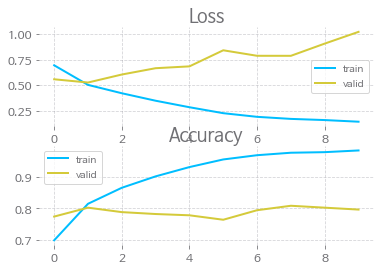

In [9]:
draw_history(history)

In [10]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_contrastive(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00,  5.01it/s, loss=0.044618, acc=0.820]
test loss : 1.115439
test acc : 0.820


In [11]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [6]:
model_path = "klue/roberta-base"

train_dataset = MyDataset_Contrastive(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Contrastive(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Contrastive(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_3"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Contrastive_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/roberta-base were not used when initializing RobertaModel: ['lm_head.dense.weight', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.decoder.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for

'cuda'

In [8]:
# train
print("============================= Train =============================")
history = train_contrastive(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [03:13,  1.52it/s, epoch=1/10, loss=0.023144, acc=0.680]
16it [00:03,  4.25it/s, loss=0.018898, acc=0.796]

294it [03:13,  1.52it/s, epoch=2/10, loss=0.017303, acc=0.795]
16it [00:03,  4.27it/s, loss=0.018969, acc=0.794]

294it [03:13,  1.52it/s, epoch=3/10, loss=0.014967, acc=0.834]
16it [00:03,  4.23it/s, loss=0.017558, acc=0.806]

294it [03:13,  1.52it/s, epoch=4/10, loss=0.012933, acc=0.866]
16it [00:03,  4.27it/s, loss=0.017586, acc=0.806]

294it [03:13,  1.52it/s, epoch=5/10, loss=0.011334, acc=0.893]
16it [00:03,  4.22it/s, loss=0.018180, acc=0.802]

294it [03:13,  1.52it/s, epoch=6/10, loss=0.009670, acc=0.916]
16it [00:03,  4.21it/s, loss=0.021619, acc=0.790]

294it [03:13,  1.52it/s, epoch=7/10, loss=0.008041, acc=0.944]
16it [00:03,  4.21it/s, loss=0.021818, acc=0.788]

294it [03:13,  1.52it/s, epoch=8/10, loss=0.006769, acc=0.957]
16it [00:03,  4.23it/s, loss=0.024537, acc=0.784]

294it [03:13,  1.52it/

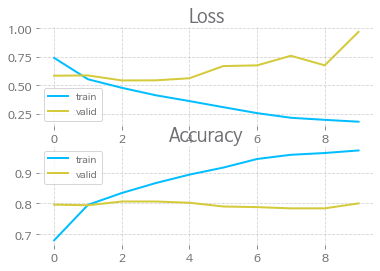

In [9]:
draw_history(history)

In [10]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_contrastive(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00,  5.07it/s, loss=0.045336, acc=0.770]
test loss : 1.133396
test acc : 0.770


In [11]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Model 4
+ Mean Pooling
+ Contrastive Loss 적용

In [4]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))


        return loss_contrastive
    
    
class My_Contrastive_Loss(nn.Module):
    def __init__(self, p=0.1, margin=2.0):
        super(My_Contrastive_Loss, self).__init__()
        
        self.p = p
        self.contrastive = ContrastiveLoss(margin)
        self.base = nn.CrossEntropyLoss()
        
    def forward(self, y_hat, output1, output2, target, c_y):
        return ((1-self.p) * self.base(y_hat, target)) + (self.p * self.contrastive(output1, output2, c_y))

In [5]:
def calc_acc(output, label):
    o_val, o_idx = torch.max(output, dim=-1)
    l_val, l_idx = torch.max(label, dim=-1)
    acc = (o_idx == l_idx).sum().item()
    return acc

def train_contrastive(model, device, optimizer, criterion, epochs, train_loader, valid_loader=None) -> dict:
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param optimizer: your optimizer
    :param criterion: loss function
    :param epoch: train epochs
    :param train_loader: train dataset
    :param valid_loader: valid dataset
    :return: history dictionary that contains train_loss, train_acc, valid_loss, valid_acc as list
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'valid_loss': [],
        'valid_acc': []
    }
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_acc = 0

        # in notebook
        # pabr = notebook.tqdm(enumerate(train_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(train_loader), file=sys.stdout)
        for batch_idx, (x, c, y) in pbar:
            x_input_ids, x_att_mask = x[0].to(device), x[1].to(device)
            c_input_ids, c_att_mask = c[0].to(device), c[1].to(device)
            target, c_y = y[0].to(device), y[1].to(device)

            optimizer.zero_grad()
            predict, output1, output2 = model(x_input_ids, x_att_mask, c_input_ids, c_att_mask)
            loss = criterion(predict, output1, output2, target, c_y)
            acc = calc_acc(predict, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

            acc = train_acc / (batch_idx * train_loader.batch_size + len(target))
            loss = train_loss / (batch_idx * train_loader.batch_size + len(target))
            pbar.set_postfix(epoch=f'{epoch}/{epochs}', loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

        train_loss = train_loss / len(train_loader)
        train_acc = train_acc / len(train_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if valid_loader is not None:
            valid_loss, valid_acc = evaluate_contrastive(model, device, criterion, valid_loader)

            history['valid_loss'].append(valid_loss)
            history['valid_acc'].append(valid_acc)
        print()

    return history


def evaluate_contrastive(model, device, criterion, data_loader):
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param criterion: loss function
    :param data_loader: valid or test Datasets
    :return: (valid or test) loss and acc
    """
    model.eval()
    total_loss = total_acc = 0

    with torch.no_grad():
        # in notebook
        # pabr = notebook.tqdm(enumerate(valid_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(data_loader), file=sys.stdout)

        for batch_idx, (x, c, y) in pbar:
            x_input_ids, x_att_mask = x[0].to(device), x[1].to(device)
            c_input_ids, c_att_mask = c[0].to(device), c[1].to(device)
            target, c_y = y[0].to(device), y[1].to(device)

            predict, output1, output2 = model(x_input_ids, x_att_mask, c_input_ids, c_att_mask)
            loss = criterion(predict, output1, output2, target, c_y)
            acc = calc_acc(predict, target)

            total_loss += loss.item()
            total_acc += acc

            acc = total_acc / (batch_idx * data_loader.batch_size + len(target))
            loss = total_loss / (batch_idx * data_loader.batch_size + len(target))
            pbar.set_postfix(loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

    total_loss = total_loss / len(data_loader)
    total_acc = total_acc / len(data_loader.dataset)

    return total_loss, total_acc

### Klue BERT-base

In [6]:
model_path = "klue/bert-base"

train_dataset = MyDataset_Contrastive(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Contrastive(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Contrastive(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_4"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Contrastive_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [8]:
# train
print("============================= Train =============================")
history = train_contrastive(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [03:12,  1.53it/s, epoch=1/10, loss=0.022275, acc=0.688]
16it [00:03,  4.21it/s, loss=0.018238, acc=0.784]

294it [03:13,  1.52it/s, epoch=2/10, loss=0.015721, acc=0.813]
16it [00:03,  4.19it/s, loss=0.018220, acc=0.788]

294it [03:13,  1.52it/s, epoch=3/10, loss=0.012809, acc=0.865]
16it [00:03,  4.19it/s, loss=0.018612, acc=0.780]

294it [03:12,  1.53it/s, epoch=4/10, loss=0.010359, acc=0.911]
16it [00:03,  4.26it/s, loss=0.019944, acc=0.798]

294it [03:12,  1.53it/s, epoch=5/10, loss=0.008099, acc=0.944]
16it [00:03,  4.23it/s, loss=0.025279, acc=0.796]

294it [03:13,  1.52it/s, epoch=6/10, loss=0.006839, acc=0.957]
16it [00:03,  4.22it/s, loss=0.024541, acc=0.790]

294it [03:13,  1.52it/s, epoch=7/10, loss=0.005609, acc=0.973]
16it [00:03,  4.20it/s, loss=0.027664, acc=0.778]

294it [03:13,  1.52it/s, epoch=8/10, loss=0.004725, acc=0.983]
16it [00:03,  4.18it/s, loss=0.026855, acc=0.804]

294it [03:13,  1.52it/

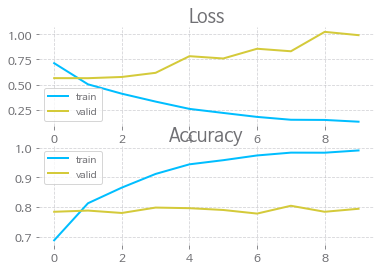

In [15]:
draw_history(history)

In [9]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_contrastive(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00,  5.09it/s, loss=0.042559, acc=0.820]
test loss : 1.063971
test acc : 0.820


In [10]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [ ]:
model_path = "klue/roberta-base"

train_dataset = MyDataset_Contrastive(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Contrastive(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Contrastive(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class_name = "MyModel_4"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Contrastive_Loss(p=0.1, margin=2)

device

In [8]:
# train
print("============================= Train =============================")
history = train_contrastive(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [03:11,  1.53it/s, epoch=1/10, loss=0.021281, acc=0.717]
16it [00:03,  4.14it/s, loss=0.017369, acc=0.784]

294it [03:12,  1.53it/s, epoch=2/10, loss=0.016844, acc=0.805]
16it [00:03,  4.27it/s, loss=0.017391, acc=0.804]

294it [03:13,  1.52it/s, epoch=3/10, loss=0.014252, acc=0.843]
16it [00:03,  4.27it/s, loss=0.017023, acc=0.796]

294it [03:13,  1.52it/s, epoch=4/10, loss=0.012443, acc=0.876]
16it [00:03,  4.25it/s, loss=0.018008, acc=0.790]

294it [03:12,  1.52it/s, epoch=5/10, loss=0.010204, acc=0.911]
16it [00:03,  4.11it/s, loss=0.019473, acc=0.808]

294it [03:13,  1.52it/s, epoch=6/10, loss=0.008372, acc=0.937]
16it [00:03,  4.18it/s, loss=0.021271, acc=0.798]

294it [03:12,  1.53it/s, epoch=7/10, loss=0.007599, acc=0.946]
16it [00:03,  4.26it/s, loss=0.025527, acc=0.792]

294it [03:12,  1.53it/s, epoch=8/10, loss=0.006061, acc=0.967]
16it [00:03,  4.15it/s, loss=0.027705, acc=0.796]

294it [03:12,  1.53it/

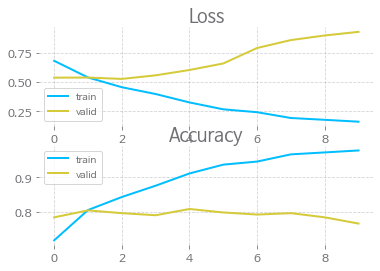

In [9]:
draw_history(history)

In [10]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_contrastive(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:00,  5.06it/s, loss=0.046921, acc=0.710]
test loss : 1.173035
test acc : 0.710


In [11]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Model 5
+ CLS Token
+ Triplet Loss 적용

In [4]:
class My_Triplet_Loss(nn.Module):
    def __init__(self, p=0.1, margin=2.0):
        super(My_Triplet_Loss, self).__init__()
        
        self.p = p
        self.triplet = nn.TripletMarginLoss(margin=1.0, p=2)
        self.CE = nn.CrossEntropyLoss()
        
    def forward(self, predict, x_embed, p_embed, n_embed, target):
        triplet = self.triplet(x_embed, p_embed, n_embed)
        ce = self.CE(predict, target)
        return ((1-self.p) * ce) + (self.p * triplet)

In [5]:
def calc_acc(output, label):
    o_val, o_idx = torch.max(output, dim=-1)
    l_val, l_idx = torch.max(label, dim=-1)
    acc = (o_idx == l_idx).sum().item()
    return acc

def train_triplet(model, device, optimizer, criterion, epochs, train_loader, valid_loader=None) -> dict:
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param optimizer: your optimizer
    :param criterion: loss function
    :param epoch: train epochs
    :param train_loader: train dataset
    :param valid_loader: valid dataset
    :return: history dictionary that contains train_loss, train_acc, valid_loss, valid_acc as list
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'valid_loss': [],
        'valid_acc': []
    }
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_acc = 0

        # in notebook
        # pabr = notebook.tqdm(enumerate(train_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(train_loader), file=sys.stdout)
        for batch_idx, (x, p, n, target) in pbar:
            anchor_inputs, anchor_atts = x[0].to(device), x[1].to(device)
            p_inputs, p_atts = p[0].to(device), p[1].to(device)
            n_inputs, n_atts = n[0].to(device), n[1].to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
            predict, anchor, pos, neg = model(anchor_inputs, anchor_atts,
                                             p_inputs, p_atts, n_inputs, n_atts)
            loss = criterion(predict, anchor, pos, neg, target)
            acc = calc_acc(predict, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

            acc = train_acc / (batch_idx * train_loader.batch_size + len(target))
            loss = train_loss / (batch_idx * train_loader.batch_size + len(target))
            pbar.set_postfix(epoch=f'{epoch}/{epochs}', loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

        train_loss = train_loss / len(train_loader)
        train_acc = train_acc / len(train_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if valid_loader is not None:
            valid_loss, valid_acc = evaluate_triplet(model, device, criterion, valid_loader)

            history['valid_loss'].append(valid_loss)
            history['valid_acc'].append(valid_acc)
        print()

    return history


def evaluate_triplet(model, device, criterion, data_loader):
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param criterion: loss function
    :param data_loader: valid or test Datasets
    :return: (valid or test) loss and acc
    """
    model.eval()
    total_loss = total_acc = 0

    with torch.no_grad():
        # in notebook
        # pabr = notebook.tqdm(enumerate(valid_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(data_loader), file=sys.stdout)

        for batch_idx, (x, p, n, target) in pbar:
            anchor_inputs, anchor_atts = x[0].to(device), x[1].to(device)
            p_inputs, p_atts = p[0].to(device), p[1].to(device)
            n_inputs, n_atts = n[0].to(device), n[1].to(device)
            target = target.to(device)

            predict, anchor, pos, neg = model(anchor_inputs, anchor_atts,
                                             p_inputs, p_atts, n_inputs, n_atts)
            loss = criterion(predict, anchor, pos, neg, target)
            acc = calc_acc(predict, target)

            total_loss += loss.item()
            total_acc += acc

            acc = total_acc / (batch_idx * data_loader.batch_size + len(target))
            loss = total_loss / (batch_idx * data_loader.batch_size + len(target))
            pbar.set_postfix(loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

    total_loss = total_loss / len(data_loader)
    total_acc = total_acc / len(data_loader.dataset)

    return total_loss, total_acc

### Klue BERT-base

In [6]:
model_path = "klue/bert-base"

train_dataset = MyDataset_Triplet(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Triplet(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Triplet(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_5"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Triplet_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [8]:
# train
print("============================= Train =============================")
history = train_triplet(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [04:55,  1.00s/it, epoch=1/10, loss=0.018001, acc=0.749]
16it [00:05,  2.81it/s, loss=0.015210, acc=0.800]

294it [04:54,  1.00s/it, epoch=2/10, loss=0.012722, acc=0.839]
16it [00:05,  2.78it/s, loss=0.017630, acc=0.794]

294it [04:54,  1.00s/it, epoch=3/10, loss=0.008811, acc=0.900]
16it [00:05,  2.83it/s, loss=0.016774, acc=0.808]

294it [04:53,  1.00it/s, epoch=4/10, loss=0.006325, acc=0.932]
16it [00:05,  2.82it/s, loss=0.019737, acc=0.792]

294it [04:53,  1.00it/s, epoch=5/10, loss=0.004394, acc=0.952]
16it [00:05,  2.82it/s, loss=0.022283, acc=0.804]

294it [04:53,  1.00it/s, epoch=6/10, loss=0.003391, acc=0.962]
16it [00:05,  2.80it/s, loss=0.021454, acc=0.800]

294it [04:53,  1.00it/s, epoch=7/10, loss=0.002554, acc=0.972]
16it [00:05,  2.78it/s, loss=0.025476, acc=0.794]

294it [04:54,  1.00s/it, epoch=8/10, loss=0.001482, acc=0.983]
16it [00:05,  2.81it/s, loss=0.033697, acc=0.788]

294it [04:52,  1.00it/

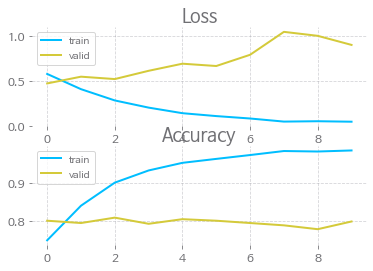

In [9]:
draw_history(history)

In [10]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_triplet(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:01,  3.42it/s, loss=0.040687, acc=0.750]
test loss : 1.017176
test acc : 0.750


In [11]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [6]:
model_path = "klue/roberta-base"

train_dataset = MyDataset_Triplet(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Triplet(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Triplet(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_5"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Triplet_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/roberta-base were not used when initializing RobertaModel: ['lm_head.dense.bias', 'lm_head.decoder.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight', 'lm_head.decoder.bias', 'lm_head.dense.weight', 'lm_head.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for

'cuda'

In [8]:
# train
print("============================= Train =============================")
history = train_triplet(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [04:54,  1.00s/it, epoch=1/10, loss=0.019473, acc=0.733]
16it [00:05,  2.82it/s, loss=0.016704, acc=0.780]

294it [04:57,  1.01s/it, epoch=2/10, loss=0.014570, acc=0.811]
16it [00:05,  2.84it/s, loss=0.015485, acc=0.820]

294it [04:57,  1.01s/it, epoch=3/10, loss=0.012314, acc=0.850]
16it [00:05,  2.81it/s, loss=0.015846, acc=0.816]

294it [04:57,  1.01s/it, epoch=4/10, loss=0.009997, acc=0.882]
16it [00:05,  2.83it/s, loss=0.016698, acc=0.818]

294it [04:56,  1.01s/it, epoch=5/10, loss=0.007998, acc=0.911]
16it [00:05,  2.80it/s, loss=0.018808, acc=0.780]

294it [04:57,  1.01s/it, epoch=6/10, loss=0.007030, acc=0.925]
16it [00:05,  2.74it/s, loss=0.020322, acc=0.798]

294it [04:53,  1.00it/s, epoch=7/10, loss=0.005542, acc=0.944]
16it [00:05,  2.80it/s, loss=0.017822, acc=0.798]

294it [04:58,  1.01s/it, epoch=8/10, loss=0.004873, acc=0.951]
16it [00:05,  2.80it/s, loss=0.019778, acc=0.796]

294it [04:58,  1.01s/i

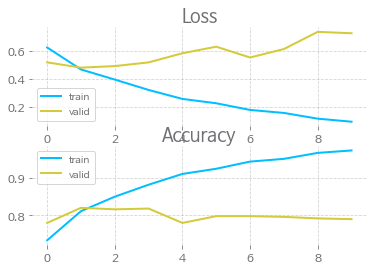

In [9]:
draw_history(history)

In [10]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_triplet(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:01,  3.43it/s, loss=0.028283, acc=0.820]
test loss : 0.707086
test acc : 0.820


In [11]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Model 6
+ Mean Pooling
+ Triplet Loss 적용

In [4]:
class My_Triplet_Loss(nn.Module):
    def __init__(self, p=0.1, margin=2.0):
        super(My_Triplet_Loss, self).__init__()
        
        self.p = p
        self.triplet = nn.TripletMarginLoss(margin=1.0, p=2)
        self.CE = nn.CrossEntropyLoss()
        
    def forward(self, predict, x_embed, p_embed, n_embed, target):
        triplet = self.triplet(x_embed, p_embed, n_embed)
        ce = self.CE(predict, target)
        return ((1-self.p) * ce) + (self.p * triplet)

In [5]:
def calc_acc(output, label):
    o_val, o_idx = torch.max(output, dim=-1)
    l_val, l_idx = torch.max(label, dim=-1)
    acc = (o_idx == l_idx).sum().item()
    return acc

def train_triplet(model, device, optimizer, criterion, epochs, train_loader, valid_loader=None) -> dict:
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param optimizer: your optimizer
    :param criterion: loss function
    :param epoch: train epochs
    :param train_loader: train dataset
    :param valid_loader: valid dataset
    :return: history dictionary that contains train_loss, train_acc, valid_loss, valid_acc as list
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'valid_loss': [],
        'valid_acc': []
    }
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = train_acc = 0

        # in notebook
        # pabr = notebook.tqdm(enumerate(train_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(train_loader), file=sys.stdout)
        for batch_idx, (x, p, n, target) in pbar:
            anchor_inputs, anchor_atts = x[0].to(device), x[1].to(device)
            p_inputs, p_atts = p[0].to(device), p[1].to(device)
            n_inputs, n_atts = n[0].to(device), n[1].to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
            predict, anchor, pos, neg = model(anchor_inputs, anchor_atts,
                                             p_inputs, p_atts, n_inputs, n_atts)
            loss = criterion(predict, anchor, pos, neg, target)
            acc = calc_acc(predict, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc

            acc = train_acc / (batch_idx * train_loader.batch_size + len(target))
            loss = train_loss / (batch_idx * train_loader.batch_size + len(target))
            pbar.set_postfix(epoch=f'{epoch}/{epochs}', loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

        train_loss = train_loss / len(train_loader)
        train_acc = train_acc / len(train_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if valid_loader is not None:
            valid_loss, valid_acc = evaluate_triplet(model, device, criterion, valid_loader)

            history['valid_loss'].append(valid_loss)
            history['valid_acc'].append(valid_acc)
        print()

    return history


def evaluate_triplet(model, device, criterion, data_loader):
    """
    :param model: your model
    :param device: your device(cuda or cpu)
    :param criterion: loss function
    :param data_loader: valid or test Datasets
    :return: (valid or test) loss and acc
    """
    model.eval()
    total_loss = total_acc = 0

    with torch.no_grad():
        # in notebook
        # pabr = notebook.tqdm(enumerate(valid_loader), file=sys.stdout)

        # in interpreter
        pbar = tqdm(enumerate(data_loader), file=sys.stdout)

        for batch_idx, (x, p, n, target) in pbar:
            anchor_inputs, anchor_atts = x[0].to(device), x[1].to(device)
            p_inputs, p_atts = p[0].to(device), p[1].to(device)
            n_inputs, n_atts = n[0].to(device), n[1].to(device)
            target = target.to(device)

            predict, anchor, pos, neg = model(anchor_inputs, anchor_atts,
                                             p_inputs, p_atts, n_inputs, n_atts)
            loss = criterion(predict, anchor, pos, neg, target)
            acc = calc_acc(predict, target)

            total_loss += loss.item()
            total_acc += acc

            acc = total_acc / (batch_idx * data_loader.batch_size + len(target))
            loss = total_loss / (batch_idx * data_loader.batch_size + len(target))
            pbar.set_postfix(loss='{:.6f}, acc={:.3f}'.format(loss, acc))
        pbar.close()

    total_loss = total_loss / len(data_loader)
    total_acc = total_acc / len(data_loader.dataset)

    return total_loss, total_acc

### Klue BERT-base

In [6]:
model_path = "klue/bert-base"

train_dataset = MyDataset_Triplet(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Triplet(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Triplet(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class_name = "MyModel_6"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Triplet_Loss(p=0.1, margin=2)

device

Some weights of the model checkpoint at klue/bert-base were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


'cuda'

In [ ]:
# train
print("============================= Train =============================")
history = train_triplet(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [04:54,  1.00s/it, epoch=1/10, loss=0.018125, acc=0.746]
16it [00:05,  2.77it/s, loss=0.015835, acc=0.796]

294it [04:58,  1.01s/it, epoch=2/10, loss=0.012636, acc=0.838]
16it [00:05,  2.79it/s, loss=0.015667, acc=0.798]

294it [04:57,  1.01s/it, epoch=3/10, loss=0.009302, acc=0.889]
16it [00:05,  2.78it/s, loss=0.019361, acc=0.766]

111it [01:52,  1.00s/it, epoch=4/10, loss=0.006540, acc=0.928]

In [ ]:
draw_history(history)

In [ ]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_triplet(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

In [ ]:
file_name = class_name+"_BERT"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

### Klue RoBerta-base

In [ ]:
model_path = "klue/roberta-base"

train_dataset = MyDataset_Triplet(train_x, train_y, model_path=model_path)
valid_dataset = MyDataset_Triplet(valid_x, valid_y, model_path=model_path)
test_dataset = MyDataset_Triplet(test_x, test_y, model_path=model_path)

train_loader = DataLoader(train_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class_name = "MyModel_6"
model = get_Model(class_name, model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = My_Triplet_Loss(p=0.1, margin=2)

device

In [ ]:
# train
print("============================= Train =============================")
history = train_triplet(model, device, optimizer, criterion, 10, train_loader, valid_loader)

In [ ]:
draw_history(history)

In [ ]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate_triplet(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

In [ ]:
file_name = class_name+"_RoBERTa"
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

## Conclusion

In [ ]:
def draw_cluster(model, data_loader, title=None):
    label_tags = ['불안', '슬픔', '기쁨']
    model.eval()
    with torch.no_grad():
        for input_ids, att_mask, label in train_loader:
            results.append(model(input_ids, att_mask).numpy())
            labels.append(label)
            
    results = np.concatenate(train_results)
    labels = np.concatenate(labels)
    
    plt.figure(figsize=(15,10), facecolor='azure')
    for label in np.unique(labels):
        tmp = result[labels==label]
        plt.scatter(tmp[:,0], tmp[:,1], label=label_tags[label])
    
    plt.title(title)
    plt.legend()
    plt.show()    

In [21]:
def draw_total(path_list, legend_labels, title):
    print("##### {} #####".format(title))
    
    plt.figure(figsize=(10,8))    
    for path, labels in zip(path_list, legend_labels):
        with open(path, 'rb') as f:
            data = pickle.load(f)
            valid_loss = data["valid_loss"]
            valid_acc = data["valid_acc"]

            plt.subplot(2,1,1)
            plt.title("Loss")
            plt.plot(valid_loss, label=labels)
            plt.legend()

            plt.subplot(2,1,2)
            plt.title('Accuracy')
            plt.plot(valid_acc, label=labels)
            plt.legend()

    plt.show()

In [22]:
path_list = ['models/MyModel_1_BERT_history.pickle', 
             'models/MyModel_3_BERT_history.pickle', 
             'models/MyModel_5_BERT_history.pickle']
legend_labels = ['Basis', 'Contrastive', 'Triplet']
title = 'CLS Token Strategy'

##### CLS Token Strategy #####


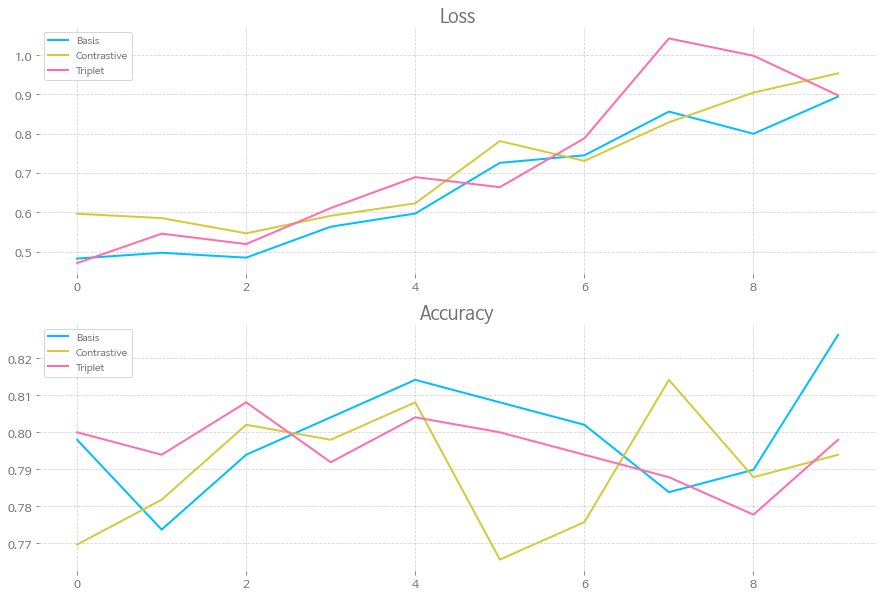

In [23]:
draw_total(path_list, legend_labels, title)